In [1]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch import tensor

import numpy as np
import pandas as pd
import networkx as nx

In [2]:
DATA_ROOT = '/home/alexanderb/LEMBAS-RNN-benchmark'

In [3]:
#try training log10(TPM+1)
#forget network parsing - just trim from raw files
#show results on training data too

In [4]:
def TF_subset(net, target_gene):
    #simpler version as per discussion w/ Cheng
    #returns all the TFs in the network that directly connect to the target gene
    return(list(net['TF'][net['Gene'] == target_gene]))

# Aims outline

Use same as first attempt but replace linear function with MML functon from LEMBAS

### Load datasets

In [5]:
net = pd.read_csv(f"{DATA_ROOT}/Full data files/network(full).tsv", sep='\t')

In [6]:
network = nx.from_pandas_edgelist(net, 
                             source='TF', 
                             target='Gene', 
                             edge_attr='Interaction')

In [7]:
gene_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/Geneexpression (full).tsv"), sep='\t', header=0)

In [8]:
TF_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/TF(full).tsv"), sep='\t', header=0)

In [9]:
import math

In [10]:
TF_expressions= TF_expressions.apply(np.log10)

In [11]:
#filter genes to nodes in network
TF_expressions = TF_expressions[[gene for gene in TF_expressions.columns if gene in list(network.nodes)]]
gene_expressions = gene_expressions[[gene for gene in gene_expressions.columns if gene in list(network.nodes)]] 

In [12]:
def TF_subset(net, target_gene):
    #simpler version as per discussion w/ Cheng
    #returns all the TFs in the network that directly connect to the target gene
    return(list(net['TF'][net['Gene'] == target_gene]))


In [14]:
target_gene = 'TP53'

In [15]:
TF_expressions = TF_expressions[TF_subset(net, target_gene)]

In [16]:
list(gene_expressions.columns).index('CASD1')

1880

### Creating dataset object

In [17]:
#torch tutorial code to use accelerator when available
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [18]:
from torch.utils.data import Dataset


class CustomTFGE(Dataset):
    def __init__(self, device, TF_expressions, gene_expressions, target_gene, network, transform=None, target_transform=None):
        '''
        Custom dataset for loading expression data across all TFs and samples and one target gene expression across all samples
        For a given index will return all TF expressions in one sample and target gene expression across all samples

        Parameters
        --------------
        device : torch device
            torch device to put dataset on, must be the same device as the model
        TF_expressions : Pandas dataframe
            pandas dataframe of TF expressions where columns are gene names and rows are samples. Expressions should be TPM normalised and log10 transformed.
        gene_expressions : Pandas dataframe
            pandas dataframe of target gene expressions, columns are gene names and rows are samples. Expressions should be TPM normalised and log10 transformed.
        target_gene : String
            String containing name of target gene for given model.
        network : networkx network
            Undirected network of the singalling pathway of interest. Used to filter TFs used when predicting target gene expression.
        '''
        #no transforms needed so set to none
        self.transform = transform
        self.target_transform = target_transform

        #load network
        self.network = network
        self.TF_expressions = TF_expressions
        self.gene_expressions = gene_expressions

        #subset to just target gene of interest
        self.target_gene = target_gene
        self.gene_expressions = self.gene_expressions[self.target_gene]

        #convert to torch tensors
        self.TF_expressions = torch.tensor(np.asarray(self.TF_expressions).T, dtype = torch.float32, device = device)
        self.gene_expressions = torch.tensor(np.asarray(self.gene_expressions), dtype = torch.float32, device = device)

    def __len__(self):
        #length of the dataset is the number of samples (not TFs in the dataset) - 15935
        return self.TF_expressions.shape[1]

    def __getitem__(self, idx):
        #get all TFs from sample correspinding to index
        TFs_exp = self.TF_expressions[:, idx]
        #get the target gene expression for the target model
        Gene_exp = self.gene_expressions[idx]
        #returns TFs for sample idx and target gene for sample idx
        return TFs_exp, Gene_exp

In [19]:
#initialise an instance of the dataset object - pass device so tensors and model on same device
dataset = CustomTFGE(device, TF_expressions=TF_expressions, gene_expressions=gene_expressions, network = network, target_gene = target_gene)
dataset

In [30]:
#new way to create train and test dataset with pytorches dataset objects
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

In [31]:
len(train_dataset)

12748

# Import LEMBAS Activation Functions

In [21]:
from activation_functions import activation_function_map

# Create Model

In [22]:
#defining the neural network
class BasicNeuralNetwork(nn.Module):
    def __init__(self, activation_function, n_tfs):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.leak = 0.01
        self.linear_in = nn.Linear(n_tfs, n_tfs)
        self.linear_out = nn.Linear(n_tfs, 1)

        # activation function
        self.activation = activation_function['activation']
        self.delta = activation_function['delta']
        self.onestepdelta_activation_factor = activation_function['onestepdelta']
    
    def forward(self, x):
        #project an input for each TF to activation with a linear layer
        expressions = self.linear_in(x)
        expressions = self.activation(expressions, self.leak)
        expressions = self.linear_out(x)
        expressions = expressions.flatten()
        return(expressions)

    

In [23]:
#put model on same device as the tensors
model = BasicNeuralNetwork(activation_function_map['MML'], TF_expressions.shape[1]).to(device)
print(model)

BasicNeuralNetwork(
  (linear_in): Linear(in_features=136, out_features=136, bias=True)
  (linear_out): Linear(in_features=136, out_features=1, bias=True)
)


## Train test loop

In [24]:
def train_loop(dataloader, model, loss_fn, optimiser):
    losses = []
    size = len(dataloader.dataset)
    
    #put model in train mode
    model.train()
    for batch, (X, y) in enumerate(dataloader):     
        #zero the gradient for each batch
        optimiser.zero_grad()

        #create a prediction
        pred = model(X)
        
        #calculate prediction loss
        loss = loss_fn(pred, y)

        #backpropogate for given loss
        loss.backward()
        optimiser.step()

        
        loss = loss.item()
        losses.append(loss)

        if batch +1 == size:
            print(f'Epoch Finished at batch {batch}\n')

        #print loss every 500 batches - this is effectively every 500th sample
        if batch % 1000 == 0:
            print(f"loss: {round(loss, 10)}")
        
    return(losses)



In [25]:
def test_loss_distribution(dataloader, model, loss_fn, target_gene):
    import matplotlib.pyplot as plt
    losses = []
    #put model in eval mode
    model.eval()
    for batch, (X, y) in enumerate(dataloader):     
        print(f"batch {batch}")

        #create a prediction - this will be 1 value for given sample and target gene
        pred = model(X)
        
        #calculate prediction loss - this will be one loss value in a distribution across samples per target gene
        loss = loss_fn(pred, y)
        

        loss = loss.item()
        print(loss)
        losses.append(loss)
        
    fig, ax = plt.subplots(ncols = 1)
    ax = plt.violinplot(losses)
    fig.suptitle(f'MSE distribution of {target_gene} expression prediction on test dataset')
    plt.savefig(f'../figures/{target_gene}_testMSE')

    return(losses)

In [37]:
#intialise hyperparameters - batch size is number of samples so that each backprop is done with the entire dataset (gradient descent not stochastic gradient descent)
#dataset is small enough for this to be fine
#investigate hyperparam tuning later
learning_rate = 1e-3
#run 1 sample at a time, but run through each sample per training epoch
batch_size = TF_expressions.shape[0]
#train on each sample 5 times
epochs =  5 #12747 * 5

#initialize MSE loss function - same as LEMBAS
loss_fn = nn.MSELoss()

#initialise same optimiser as LEMBAS
optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [27]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [39]:
len(test_dataloader)

1

In [36]:
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    losses = train_loop(train_dataloader, model, loss_fn, optimiser)


Epoch 1
-------------------------------
loss: nan
Epoch 2
-------------------------------
loss: nan
Epoch 3
-------------------------------
loss: nan
Epoch 4
-------------------------------
loss: nan
Epoch 5
-------------------------------
loss: nan


batch 0
nan


ValueError: `dataset` input should have multiple elements.

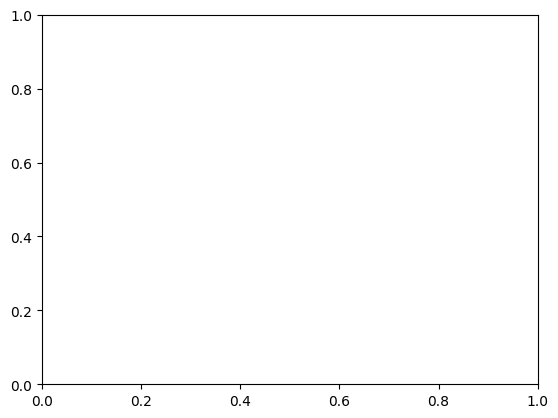

In [29]:
MSE_distrubution = test_loss_distribution(test_dataloader, model, loss_fn, target_gene)

# Saving model

In [ ]:
torch.save(model, 'models/linear_with_network.pth')

In [ ]:
#How to load for reference
model = torch.load('models/linear_with_network.pth', weights_only=False)

In [ ]:
results_df = pd.DataFrame(index = gene_expressions.columns, columns = ['train_score', 'test_score'])